In [18]:
"""
This notebook presents guides for simulating 2D horizontally-periodic Rayleigh-Benard convection 
using Dedalus framework as written in following site 
https://dedalus-project.readthedocs.io/en/latest/pages/examples/ivp_2d_rayleigh_benard.html#
"""
import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3


Computational domain of problem is $[L_x\times L_z]:=[4\times 1]$ with a corresponding mesh of $[N_x\times N_z] := [256\times 64]$


In [19]:
# Parameters
Xmin, Xmax = 0., 1.         # computational domain of x-dimension
Zmin, Zmax = 0., 1.         # computational domain of z-dimension
Nx, Nz = 64, 64            # number of points

The system is governed by

$
\begin{equation}
\nabla\cdot \vec{u} = 0,
\end{equation}
$

$
\begin{equation}
\partial_t \vec{u}+\vec{u}\cdot\nabla\vec{u} =\nu\nabla^2\vec{u} -\nabla p + B\vec{e}_z,
\end{equation}
$

$
\begin{equation}
\partial_t B +\vec{u}\cdot\nabla B = \kappa\nabla^2 B.
\end{equation}
$

where $\vec{u}$, $p$, $B$, $\vec{e}_z$, $\kappa$, and $\nu$ are the fluid velocity, pressure, buoyancy term, unit vector in the vertical, thermal diffusivity, and kinematic viscosity. The buoyancy term is used for representing the temperature and to simplize computation.

In this case, we non-dimensionalize the problem by using domain height $h=L_z=1$ and the freefall time. Therefore,the Rayleigh number and Prandtl number can be determined by


\begin{align}
Ra := \frac{1}{\nu\kappa},\quad Pr := \frac{\nu}{\kappa}
\end{align}


Based on that, we can obtain the thermal diffusivity $\kappa$ and kinematic viscosity $\nu$.

\begin{align}
\Rightarrow \quad \kappa := (RaPr)^{-1/2},\quad \nu := \left(\frac{Ra}{Pr}\right)^{-1/2}
\end{align}

In [20]:
Ra = 2e6    # Rayleigh number
Pr = 1.     # Prandtl number
kappa = (Ra*Pr)**(-1./2.)   # thermal diffusivity
nu = (Ra/Pr)**(-1./2.)      # kinematic viscosity

Governing equations are modified to fit with the Dedalus framework:


\begin{equation}
\nabla\cdot \vec{u} = 0,
\end{equation}



\begin{equation}
\partial_t \vec{u} - \nu\nabla^2\vec{u} +\nabla p - B\vec{e}_z = -\vec{u}\cdot\nabla\vec{u},
\end{equation}



\begin{equation}
\partial_t B - \kappa\nabla^2 B = -\vec{u}\cdot\nabla B.
\end{equation}


To begin with, we must create basis for problem, including the mesh system for present 2D problem and defining data type of output.

In [21]:
dtype = np.float64 # = double
dealias = 3/2

# Bases
coords = d3.CartesianCoordinates('x','z')
dist = d3.Distributor(coords, dtype=dtype)
xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(Xmin, Xmax), dealias=dealias)
zbasis = d3.ChebyshevT(coords['z'], size=Nz, bounds=(Zmin, Zmax), dealias=dealias)

Now, we will instantiate fields which will appears within the problem, including velocity $\vec{u}$, buoyancy $b$ and pressure $p$.

In [22]:
# Fields
p = dist.Field(name='p', bases=(xbasis,zbasis)) # create pressure field
b = dist.Field(name='b', bases=(xbasis,zbasis)) # create buoyancy field
u = dist.VectorField(coords, name='u', bases=(xbasis,zbasis)) # create velocity field

First, we consider the incompressible flow condition's equation:

\begin{align}
\nabla\cdot \vec{u} = 0
\end{align}

When implementing this divergence equation, there is a few error if one variable is underdetermined. So, we will use Gauge condition in present Dedalus v3, read here [https://dedalus-project.readthedocs.io/en/latest/pages/gauge_conditions.html]. Here, the divergence equation is expanded the system by adding a spatially-constant variable ($\tau_p$) for solving pressure field. As a result, the equation is replaced by

\begin{align}
\nabla\cdot \vec{u} + \tau_p= 0
\end{align}

In Dedalus, we need to create a corresponding sub-field for $\tau_p$

In [23]:
# Substitutions
x, z = dist.local_grids(xbasis, zbasis)
ex, ez = coords.unit_vector_fields(dist)
lift_basis = zbasis.derivative_basis(1)
lift = lambda A: d3.Lift(A, lift_basis, -1)

# create constant sub-field for incompressible flow condition's equation
tau_p = dist.Field(name='tau_p') 
# because this term is only a contant added to the equation, we don't need to instantiate it for bases system

# create constant sub-field for bouyancy term
tau_b1 = dist.Field(name='tau_b1', bases=xbasis)
tau_b2 = dist.Field(name='tau_b2', bases=xbasis)
grad_b = d3.grad(b) + ez*lift(tau_b1) # First-order reduction

tau_u1 = dist.VectorField(coords, name='tau_u1', bases=xbasis) 
tau_u2 = dist.VectorField(coords, name='tau_u2', bases=xbasis)
grad_u = d3.grad(u) + ez*lift(tau_u1) # First-order reduction

When we have all the fields for solving, we must build the IVP problem and introcude fields to the solver. At this step, we don't have full field for solving all three governing equations, so we just introduce corresponding codes to perform this.

Build problem for the solver

In [24]:
# Problem
problem = d3.IVP([p, tau_p, u, tau_u1, tau_u2, b, tau_b1, tau_b2], namespace=locals())

Adding the first equation

\begin{align}
tr(\nabla\cdot \vec{u}) + \tau_p = 0
\end{align}

In [25]:
# equation 1
problem.add_equation("trace(grad_u) + tau_p = 0")
problem.add_equation("integ(p) = 0") # Pressure gauge

{'LHS': Integrate(Integrate(<Field 124864538521824>)),
 'RHS': 0,
 'condition': 'True',
 'tensorsig': (),
 'dtype': numpy.float64,
 'M': 0,
 'L': Integrate(Integrate(<Field 124864538521824>)),
 'F': <Field 124864538318064>,
 'domain': <dedalus.core.domain.Domain at 0x71904a797a70>,
 'matrix_dependence': array([ True,  True]),
 'matrix_coupling': array([False,  True])}

Adding the second equation

\begin{align}
\partial_t \vec{u} - \nu\nabla^2\vec{u} +\nabla p - B\vec{e}_z = -\vec{u}\cdot\nabla\vec{u}
\end{align}

In [26]:
# equation 2
problem.add_equation("dt(u) - nu*div(grad_u) + grad(p) - b*ez + lift(tau_u2) = - u@grad(u)")

{'LHS': Add(Add(Add(Add(Convert(dt(<Field 124864538515200>)), Mul(-1, Mul(0.0007071067811865475, Div(Add(Grad(<Field 124864538515200>), Mul(<Field 124864538694176>, Mul(<Field 124864679864144>, <Field 124864677073536>))))))), Convert(Grad(<Field 124864538521824>))), Convert(Mul(-1, Mul(<Field 124864539877520>, <Field 124864538694176>)))), Convert(Mul(<Field 124864679864144>, <Field 124865538990656>))),
 'RHS': Dot(Mul(-1, <Field 124864538515200>), Grad(<Field 124864538515200>)),
 'condition': 'True',
 'tensorsig': (<dedalus.core.coords.CartesianCoordinates at 0x7190533c3110>,),
 'dtype': dtype('float64'),
 'M': Convert(<Field 124864538515200>),
 'L': Add(Add(Add(Mul(-1, Mul(0.0007071067811865475, Div(Add(Grad(<Field 124864538515200>), Mul(<Field 124864538694176>, Mul(<Field 124864679864144>, <Field 124864677073536>)))))), Convert(Grad(<Field 124864538521824>))), Convert(Mul(-1, Mul(<Field 124864539877520>, <Field 124864538694176>)))), Convert(Mul(<Field 124864679864144>, <Field 1248655

Adding the third equation

\begin{align}
\partial_t B - \kappa\nabla^2 B = -\vec{u}\cdot\nabla B
\end{align}

In [27]:
# equation 3
problem.add_equation("dt(b) - kappa*div(grad_b) + lift(tau_b2) = - u@grad(b)")

{'LHS': Add(Add(Convert(dt(<Field 124864539877520>)), Mul(-1, Mul(0.0007071067811865475, Div(Add(Grad(<Field 124864539877520>), Mul(<Field 124864538694176>, Mul(<Field 124864679864144>, <Field 124864677844208>))))))), Convert(Mul(<Field 124864679864144>, <Field 124864538705840>))),
 'RHS': Dot(Mul(-1, <Field 124864538515200>), Grad(<Field 124864539877520>)),
 'condition': 'True',
 'tensorsig': (),
 'dtype': dtype('float64'),
 'M': Convert(<Field 124864539877520>),
 'L': Add(Mul(-1, Mul(0.0007071067811865475, Div(Add(Grad(<Field 124864539877520>), Mul(<Field 124864538694176>, Mul(<Field 124864679864144>, <Field 124864677844208>)))))), Convert(Mul(<Field 124864679864144>, <Field 124864538705840>))),
 'F': Convert(Dot(Mul(-1, <Field 124864538515200>), Grad(<Field 124864539877520>))),
 'domain': <dedalus.core.domain.Domain at 0x71904a7acd40>,
 'matrix_dependence': array([ True,  True]),
 'matrix_coupling': array([False,  True])}

Set up the boundary conditions

In [28]:
# for buoyancy
problem.add_equation("b(z=Zmin) = 1")
problem.add_equation("b(z=Zmax) = 0")
# for velocity
problem.add_equation("u(z=Zmin) = 0")
problem.add_equation("u(z=Zmax) = 0")

{'LHS': interp(<Field 124864538515200>, z=1.0),
 'RHS': 0,
 'condition': 'True',
 'tensorsig': (<dedalus.core.coords.CartesianCoordinates at 0x7190533c3110>,),
 'dtype': numpy.float64,
 'M': 0,
 'L': interp(<Field 124864538515200>, z=1.0),
 'F': <Field 124864678049888>,
 'domain': <dedalus.core.domain.Domain at 0x71904a797320>,
 'matrix_dependence': array([False,  True]),
 'matrix_coupling': array([False,  True])}

Solver

In [29]:
stop_sim_time = 50
timestepper = d3.RK222
# Solver
solver = problem.build_solver(timestepper)
solver.stop_sim_time = stop_sim_time

2024-05-16 03:38:22,047 subsystems 0/1 INFO :: Building subproblem matrices 1/32 (~3%) Elapsed: 0s, Remaining: 5s, Rate: 5.8e+00/s
2024-05-16 03:38:22,275 subsystems 0/1 INFO :: Building subproblem matrices 4/32 (~12%) Elapsed: 0s, Remaining: 3s, Rate: 1.0e+01/s
2024-05-16 03:38:22,554 subsystems 0/1 INFO :: Building subproblem matrices 8/32 (~25%) Elapsed: 1s, Remaining: 2s, Rate: 1.2e+01/s
2024-05-16 03:38:22,855 subsystems 0/1 INFO :: Building subproblem matrices 12/32 (~38%) Elapsed: 1s, Remaining: 2s, Rate: 1.2e+01/s
2024-05-16 03:38:23,151 subsystems 0/1 INFO :: Building subproblem matrices 16/32 (~50%) Elapsed: 1s, Remaining: 1s, Rate: 1.3e+01/s
2024-05-16 03:38:23,343 subsystems 0/1 INFO :: Building subproblem matrices 20/32 (~62%) Elapsed: 1s, Remaining: 1s, Rate: 1.4e+01/s
2024-05-16 03:38:23,586 subsystems 0/1 INFO :: Building subproblem matrices 24/32 (~75%) Elapsed: 2s, Remaining: 1s, Rate: 1.4e+01/s
2024-05-16 03:38:23,856 subsystems 0/1 INFO :: Building subproblem matric

Set up initial conditions

In [30]:
b.fill_random('g', seed=42, distribution='normal', scale=1e-3) # Random noise
b['g'] *= z * (Zmax - z) # Damp noise at walls
b['g'] += Zmax - z # Add linear background

In [31]:
# Analysis
snapshots = solver.evaluator.add_file_handler('snapshots', sim_dt=0.25, max_writes=50)
snapshots.add_task(b, name='buoyancy')
snapshots.add_task(-d3.div(d3.skew(u)), name='vorticity')

In [32]:
max_timestep = 0.125
# CFL
CFL = d3.CFL(solver, initial_dt=max_timestep, cadence=10, safety=0.5, threshold=0.05,
             max_change=1.5, min_change=0.5, max_dt=max_timestep)
CFL.add_velocity(u)

In [33]:
# Flow properties
flow = d3.GlobalFlowProperty(solver, cadence=10)
flow.add_property(np.sqrt(u@u)/nu, name='Re')

Starting main loop
Completed iteration 1000, time=23.962
[[9.99055666e-01 9.91502375e-01 9.76401873e-01 ... 2.63877141e-02
  9.50352520e-03 1.05614499e-03]
 [9.99008682e-01 9.91079539e-01 9.75227621e-01 ... 2.55457725e-02
  9.20026096e-03 1.02244701e-03]
 [9.98961754e-01 9.90657213e-01 9.74054829e-01 ... 2.46840320e-02
  8.88986374e-03 9.87955786e-04]
 ...
 [9.99195026e-01 9.92756521e-01 9.79884807e-01 ... 2.87928685e-02
  1.03698597e-02 1.15241296e-03]
 [9.99149018e-01 9.92342487e-01 9.78734983e-01 ... 2.80110914e-02
  1.00882639e-02 1.12112090e-03]
 [9.99102506e-01 9.91923916e-01 9.77572550e-01 ... 2.72094743e-02
  9.79952146e-03 1.08903561e-03]]
Completed iteration 2000, time=37.147
[[9.99842206e-01 9.98511923e-01 9.95720579e-01 ... 3.88661167e-03
  1.45335489e-03 1.70309229e-04]
 [9.99849897e-01 9.98579499e-01 9.95907338e-01 ... 3.83223700e-03
  1.43420312e-03 1.68029773e-04]
 [9.99853113e-01 9.98608533e-01 9.95989857e-01 ... 3.87950091e-03
  1.45045406e-03 1.69526539e-04]
 ...
 [9

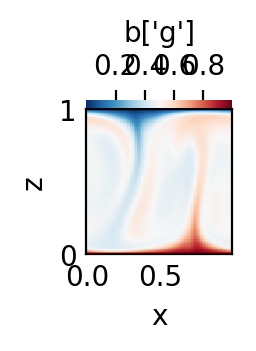

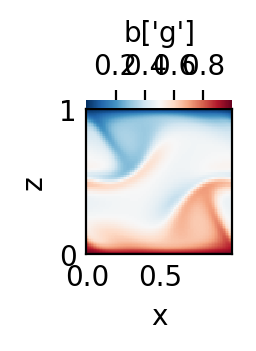

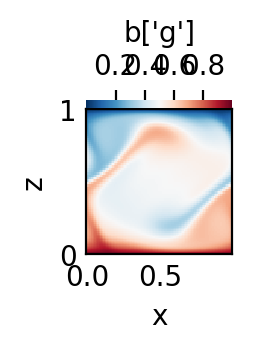

In [34]:
from dedalus.extras.plot_tools import plot_bot_2d

figkw = {'figsize':(1,1), 'dpi':200}
# Main loop
# timestep = 0.05
print('Starting main loop')
while solver.proceed:
    timestep = CFL.compute_timestep()
    solver.step(timestep)
    if solver.iteration % 1000 == 0:
        print('Completed iteration {}, time={:.3f}'.format(solver.iteration, solver.sim_time))
        print(b['g'])
        b.layout.grid_space
        plot_bot_2d(b, figkw=figkw, title="b['g']")
        plt.savefig("Reference_RBC_simulation_bouyancy_t{:.3f}.png".format(solver.sim_time), dpi=200)
        # plt.close()
